In [ ]:
# CELL 1: SETUP, DRIVE MOUNT & ROBUST VIDEO EXTRACTION
import os
import glob
from google.colab import drive
drive.mount('/content/drive')

PROJECT_NAME = 'New_Monument_Reconstruction'
DRIVE_ROOT = f'/content/drive/MyDrive/{PROJECT_NAME}'
DATA_PATH = '/content/data'
IMG_DIR = f'{DATA_PATH}/images'

for folder in [
    DRIVE_ROOT,
    f'{DRIVE_ROOT}/point_clouds',
    f'{DRIVE_ROOT}/3dgs_output',
    f'{DRIVE_ROOT}/depth_maps',
    DATA_PATH,
    IMG_DIR
]:
    os.makedirs(folder, exist_ok=True)

print(f"Created Drive folder at: {DRIVE_ROOT}")

!pip install yt-dlp -q
VIDEO_URL = "https://www.youtube.com/watch?v=0NSq1-Ne26Y"

print("\nDownloading drone video...")
!yt-dlp -f 'bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]/best' {VIDEO_URL} -o "/content/drone_flight.mp4"

# ROBUST FRAME EXTRACTION
print("\nExtracting frames")
!ffmpeg -i /content/drone_flight.mp4 -vf fps=2 -q:v 2 {IMG_DIR}/frame_%05d.jpg -hide_banner -loglevel error

# Verification
extracted_images = glob.glob(f"{IMG_DIR}/*.jpg")
if len(extracted_images) > 0:
    print(f"Extraction complete! Successfully saved {len(extracted_images)} images.")
else:
    print("Extraction failed. Please check the video URL.")

with open('/content/env_vars.txt', 'w') as f:
    f.write(f"{DATA_PATH}\n{DRIVE_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created Drive folder at: /content/drive/MyDrive/New_Monument_Reconstruction

[youtube] Extracting URL: https://www.youtube.com/watch?v=0NSq1-Ne26Y
[youtube] 0NSq1-Ne26Y: Downloading webpage
[youtube] 0NSq1-Ne26Y: Downloading android vr player API JSON
[info] 0NSq1-Ne26Y: Downloading 1 format(s): 399+140
[download] /content/drone_flight.mp4 has already been downloaded

Extracting frames using FFmpeg...
Extraction complete! Successfully saved 234 images.


In [ ]:
# CELL 2: CORE DEPENDENCIES

print("Installing COLMAP and Python packages")
!apt-get update -qq
!apt-get install -y colmap -qq
!pip install plyfile tqdm ninja opencv-python pycolmap timm -q

print("\nInstalling HLOC (Hierarchical Localization)")
!git clone --recursive https://github.com/cvg/Hierarchical-Localization.git /content/hloc -q 2>/dev/null || true
!pip install -e /content/hloc -q

print("\nSetting up 3D Gaussian Splatting")
!git clone --recursive https://github.com/graphdeco-inria/gaussian-splatting.git /content/gaussian-splatting -q 2>/dev/null || true
!pip install /content/gaussian-splatting/submodules/diff-gaussian-rasterization -q
!pip install /content/gaussian-splatting/submodules/simple-knn -q

print("\nAll dependencies installed")

Installing COLMAP and Python packages
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

Installing HLOC (Hierarchical Localization)
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 114.3 MB/s eta 0:00:00

Setting up 3D Gaussian Splatting
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done

All dependencies installed


In [ ]:
# MANUALLY INSTALL MISSING SUPERGLUE SUBMODULE
import os

print("Downloading missing SuperGlue submodule")
!mkdir -p /content/hloc/third_party
!rm -rf /content/hloc/third_party/SuperGluePretrainedNetwork
!git clone https://github.com/magicleap/SuperGluePretrainedNetwork.git /content/hloc/third_party/SuperGluePretrainedNetwork -q

if os.path.exists('/content/hloc/third_party/SuperGluePretrainedNetwork/models'):
    print("SuperGlue successfully installed! You can now run Cell 3.")
else:
    print("Download failed")

SuperGlue successfully installed! You can now run Cell 3.


In [ ]:
# CELL 3: SPARSE RECONSTRUCTION (HLOC + COLMAP)

import os
import shutil
from pathlib import Path
import sys

with open('/content/env_vars.txt', 'r') as f:
    DATA_PATH, DRIVE_ROOT = f.read().splitlines()

sys.path.insert(0, '/content/hloc')
os.environ['QT_QPA_PLATFORM'] = 'offscreen'
from hloc import extract_features, match_features, reconstruction, pairs_from_exhaustive

images_dir = Path(f"{DATA_PATH}/images")
sfm_dir = Path(f"{DATA_PATH}/sfm_workspace")
sfm_dir.mkdir(parents=True, exist_ok=True)

print("Extracting SuperPoint Features")
feat_conf = extract_features.confs['superpoint_aachen']
feat_path = extract_features.main(feat_conf, images_dir, sfm_dir)

print("\nGenerating Image Pairs")
pairs_path = sfm_dir / 'pairs.txt'
img_list = [p.name for p in images_dir.iterdir() if p.suffix.lower() in ['.jpg', '.png']]
pairs_from_exhaustive.main(pairs_path, image_list=img_list)

print("\nMatching features with SuperGlue")
match_conf = match_features.confs['superglue']
match_path = match_features.main(match_conf, pairs_path, feat_conf['output'], sfm_dir)

print("\nRunning COLMAP 3D Reconstruction")
model = reconstruction.main(sfm_dir / 'sparse_model', images_dir, pairs_path, feat_path, match_path, verbose=False)

# Format the sparse output for 3DGS
sparse_dst = Path(f"{DATA_PATH}/sparse/0")
sparse_dst.mkdir(parents=True, exist_ok=True)

for f in ['cameras.bin', 'images.bin', 'points3D.bin']:
    src_file = sfm_dir / 'sparse_model' / '0' / f
    if src_file.exists():
        shutil.copy(str(src_file), str(sparse_dst / f))

# Convert sparse model to .ply and save to drive
!colmap model_converter \
    --input_path {DATA_PATH}/sparse/0 \
    --output_path {DRIVE_ROOT}/point_clouds/sparse_pointcloud.ply \
    --output_type PLY

print(f"\nSparse reconstruction complete. Saved to: {DRIVE_ROOT}/point_clouds/sparse_pointcloud.ply")

[2026/04/01 08:33:19 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-r1024',
 'preprocessing': {'grayscale': True, 'resize_max': 1024}}
[2026/04/01 08:33:19 hloc INFO] Found 234 images in root /content/data/images.


Extracting SuperPoint Features
Loaded SuperPoint model


100%|██████████| 234/234 [00:03<00:00, 61.72it/s]
[2026/04/01 08:33:23 hloc INFO] Finished exporting features.
[2026/04/01 08:33:23 hloc INFO] Found 27261 pairs.
[2026/04/01 08:33:23 hloc INFO] Matching local features with configuration:
{'model': {'name': 'superglue',
           'sinkhorn_iterations': 50,
           'weights': 'outdoor'},
 'output': 'matches-superglue'}



Generating Image Pairs

Matching features with SuperGlue
Loaded SuperGlue model ("outdoor" weights)


100%|██████████| 27261/27261 [24:39<00:00, 18.42it/s]
[2026/04/01 08:58:03 hloc INFO] Finished exporting matches.
[2026/04/01 08:58:03 hloc INFO] Writing COLMAP logs to /content/data/sfm_workspace/sparse_model/colmap.LOG.*
[2026/04/01 08:58:03 hloc INFO] Creating an empty database...
[2026/04/01 08:58:03 hloc INFO] Importing images into the database...



Running COLMAP 3D Reconstruction


[2026/04/01 08:58:10 hloc INFO] Importing features into the database...
100%|██████████| 234/234 [00:00<00:00, 1123.66it/s]
[2026/04/01 08:58:10 hloc INFO] Importing matches into the database...
100%|██████████| 27261/27261 [00:30<00:00, 880.21it/s]
[2026/04/01 08:58:41 hloc INFO] Performing geometric verification of the matches...
[2026/04/01 09:01:00 hloc INFO] Running 3D reconstruction...
Reconstruction 0: 100%|██████████| 234/234 [17:51<00:00,  4.58s/images, registered]
[2026/04/01 09:18:53 hloc INFO] Reconstructed 1 model(s).
[2026/04/01 09:18:53 hloc INFO] Largest model is #0 with 234 images.
[2026/04/01 09:18:53 hloc INFO] Reconstruction statistics:
Reconstruction:
	num_rigs = 234
	num_cameras = 234
	num_frames = 234
	num_reg_frames = 234
	num_images = 234
	num_points3D = 20205
	num_observations = 238238
	mean_track_length = 11.791
	mean_observations_per_image = 1018.11
	mean_reprojection_error = 1.44611
	num_input_images = 234


F0401 09:18:53.456909 22793 reconstruction.cc:745] cameras, images, points3D files do not exist at /content/data/sparse/0
*** Check failure stack trace: ***
    @     0x78390cec6b03  google::LogMessage::Fail()
    @     0x78390cece9d1  google::LogMessage::SendToLog()
    @     0x78390cec67c2  google::LogMessage::Flush()
    @     0x78390cec878f  google::LogMessageFatal::~LogMessageFatal()
    @     0x5645313746f2  colmap::Reconstruction::Read()
    @     0x5645312dc46e  colmap::RunModelConverter()
    @     0x5645312b7499  main
    @     0x78390b13fd90  (unknown)
    @     0x78390b13fe40  __libc_start_main
    @     0x5645312ba3e5  _start

Sparse reconstruction complete. Saved to: /content/drive/MyDrive/New_Monument_Reconstruction/point_clouds/sparse_pointcloud.ply


In [ ]:
# HOTFIX: LOCATE SFM FILES AND GENERATE PLY (temporary block, only if upper one doesnt find file)

import os
import shutil
from pathlib import Path

# Read paths
with open('/content/env_vars.txt', 'r') as f:
    DATA_PATH, DRIVE_ROOT = f.read().splitlines()

sfm_dir = Path(f"{DATA_PATH}/sfm_workspace")
sparse_dst = Path(f"{DATA_PATH}/sparse/0")
sparse_dst.mkdir(parents=True, exist_ok=True)

print("Hunting for the completed SfM files...")

# Find where HLOC actually saved the files
found_model_dir = None
for root, dirs, files in os.walk(sfm_dir):
    if 'cameras.bin' in files or 'cameras.txt' in files:
        found_model_dir = Path(root)
        break

if found_model_dir:
    print(f"Found model files at: {found_model_dir}")

    # Copy them to the exact folder COLMAP expects
    for f in ['cameras.bin', 'images.bin', 'points3D.bin', 'cameras.txt', 'images.txt', 'points3D.txt']:
        src_file = found_model_dir / f
        if src_file.exists():
            shutil.copy(str(src_file), str(sparse_dst / f))
            print(f"Copied {f}")

    print("\nConverting model to PLY format...")
    !colmap model_converter \
        --input_path {DATA_PATH}/sparse/0 \
        --output_path {DRIVE_ROOT}/point_clouds/sparse_pointcloud.ply \
        --output_type PLY

    if os.path.exists(f"{DRIVE_ROOT}/point_clouds/sparse_pointcloud.ply"):
        print(f"\nSUCCESS! Sparse point cloud saved to Drive: {DRIVE_ROOT}/point_clouds/sparse_pointcloud.ply")
        print("You can now proceed to run Cell 4 (Dense Reconstruction).")
    else:
        print("\nConverter failed. Check logs.")
else:
    print("Could not find the model files in the workspace. Something else went wrong.")

Hunting for the completed SfM files...
Found model files at: /content/data/sfm_workspace/sparse_model
Copied cameras.bin
Copied images.bin
Copied points3D.bin

Converting model to PLY format...

SUCCESS! Sparse point cloud saved to Drive: /content/drive/MyDrive/New_Monument_Reconstruction/point_clouds/sparse_pointcloud.ply
You can now proceed to run Cell 4 (Dense Reconstruction).


In [ ]:
# CELL 5: UNDISTORTION & 3D GAUSSIAN SPLATTING TRAINING
import os
import shutil

with open('/content/env_vars.txt', 'r') as f:
    DATA_PATH, DRIVE_ROOT = f.read().splitlines()

UNDISTORTED_DIR = f"{DATA_PATH}/undistorted"
os.makedirs(f"{UNDISTORTED_DIR}/sparse/0", exist_ok=True)

print("Undistorting images to PINHOLE camera model for 3DGS...")
!colmap image_undistorter \
    --image_path {DATA_PATH}/images \
    --input_path {DATA_PATH}/sparse/0 \
    --output_path {UNDISTORTED_DIR} \
    --output_type COLMAP

print("Formatting sparse directory...")
for f in ['cameras.bin', 'images.bin', 'points3D.bin']:
    src = f"{UNDISTORTED_DIR}/sparse/{f}"
    dst = f"{UNDISTORTED_DIR}/sparse/0/{f}"
    if os.path.exists(src):
        shutil.copy(src, dst)

os.chdir('/content/gaussian-splatting')

ITERATIONS = 30000
OUTPUT_DIR = '/content/3dgs_workspace'

print(f"\n Starting 3DGS Training for {ITERATIONS} iterations...")
!python train.py \
    -s {UNDISTORTED_DIR} \
    -m {OUTPUT_DIR} \
    --iterations {ITERATIONS} \
    --quiet

print("\nTraining complete!")

final_ply = f"{OUTPUT_DIR}/point_cloud/iteration_{ITERATIONS}/point_cloud.ply"

if os.path.exists(final_ply):
    drive_dest = f"{DRIVE_ROOT}/3dgs_output/3dgs_model_{ITERATIONS}.ply"
    shutil.copy(final_ply, drive_dest)
    print(f"\n3DGS Model saved to Drive: {drive_dest}")
    print("Download this file and drag it directly into https://supersplat.playcanvas.com/")
else:
    print("\nError: Could not locate the 3DGS output file.")

Undistorting images to PINHOLE camera model for 3DGS...

Reading reconstruction

 => Reconstruction with 234 images and 20205 points

Image undistortion

Undistorting image [1/234]
Undistorting image [2/234]
Undistorting image [3/234]
Undistorting image [4/234]
Undistorting image [5/234]
Undistorting image [6/234]
Undistorting image [7/234]
Undistorting image [8/234]
Undistorting image [9/234]
Undistorting image [10/234]
Undistorting image [11/234]
Undistorting image [12/234]
Undistorting image [13/234]
Undistorting image [14/234]
Undistorting image [15/234]
Undistorting image [16/234]
Undistorting image [17/234]
Undistorting image [18/234]
Undistorting image [19/234]
Undistorting image [20/234]
Undistorting image [21/234]
Undistorting image [22/234]
Undistorting image [23/234]
Undistorting image [24/234]
Undistorting image [25/234]
Undistorting image [26/234]
Undistorting image [27/234]
Undistorting image [28/234]
Undistorting image [29/234]
Undistorting image [30/234]
Undistorting im

Loading MiDaS small model...


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading weights:  None


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 424MB/s]


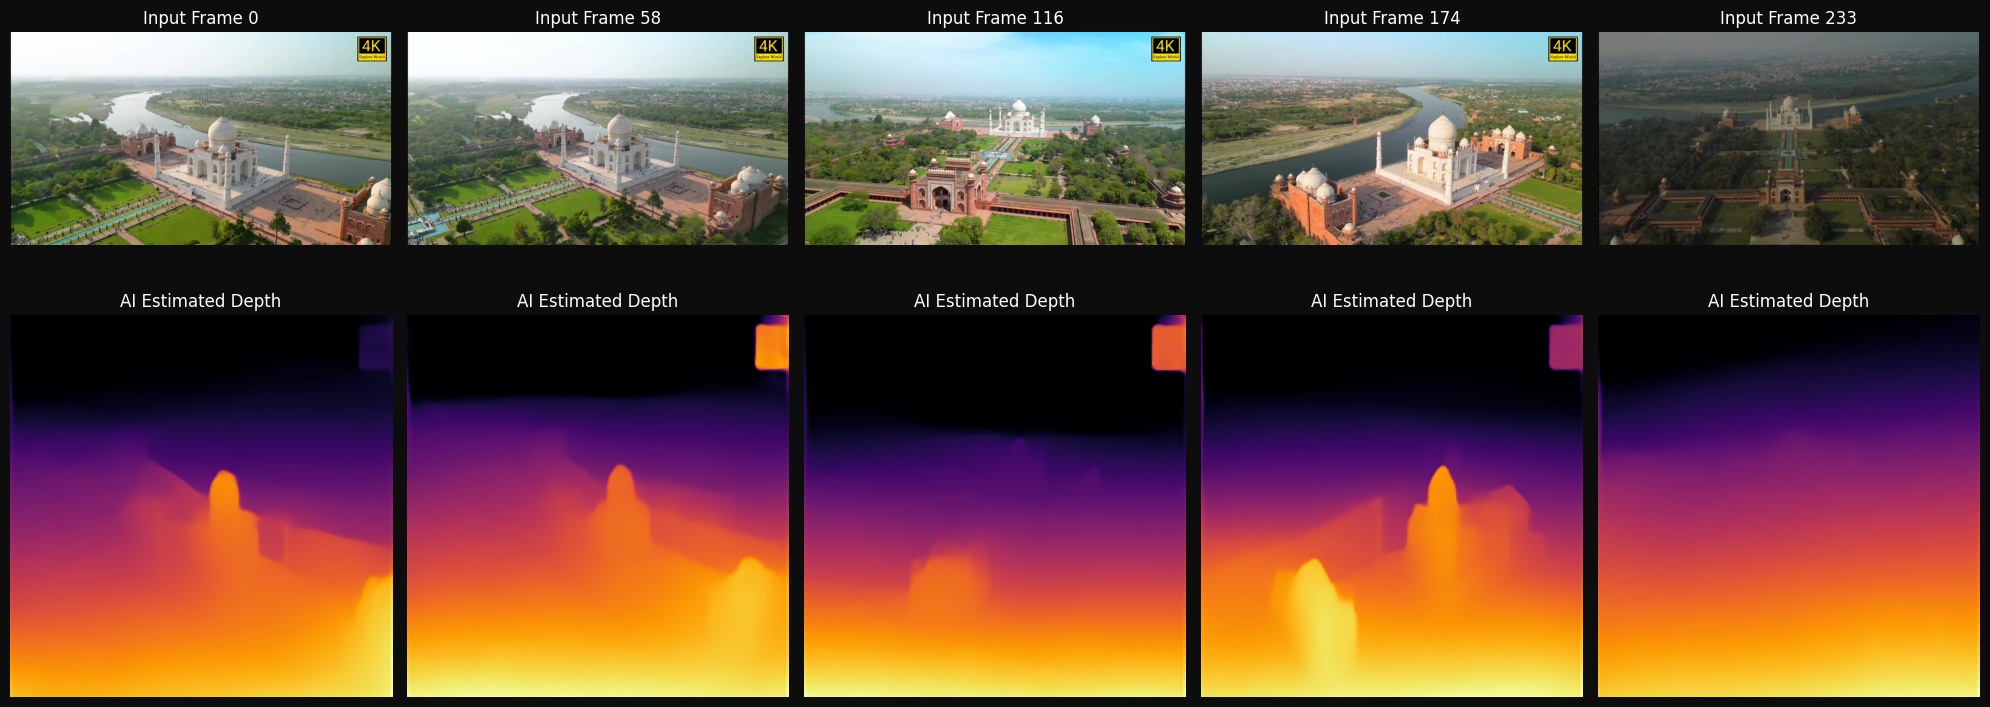


Depth maps saved to Drive: /content/drive/MyDrive/New_Monument_Reconstruction/depth_maps/midas_visualization.png


In [ ]:
# CELL 6: MiDaS DEPTH ESTIMATION VISUALIZATION
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

with open('/content/env_vars.txt', 'r') as f:
    DATA_PATH, DRIVE_ROOT = f.read().splitlines()

print('Loading MiDaS small model...')
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small')
midas.eval().cuda()

def estimate_depth(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).cuda()
    with torch.no_grad():
        depth = midas(img)
    return depth.squeeze().cpu().numpy()

# Get 5 evenly spaced images from the original dataset
all_imgs = sorted(glob.glob(f'{DATA_PATH}/images/*.jpg'))

if len(all_imgs) > 0:
    indices = np.linspace(0, len(all_imgs)-1, 5, dtype=int)
    sample_imgs = [all_imgs[i] for i in indices]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.patch.set_facecolor('#0d0d0d')

    for i, img_path in enumerate(sample_imgs):
        img_display = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        depth = estimate_depth(img_path)

        axes[0][i].imshow(img_display)
        axes[0][i].axis('off')
        axes[0][i].set_title(f'Input Frame {indices[i]}', color='white')

        axes[1][i].imshow(depth, cmap='inferno')
        axes[1][i].axis('off')
        axes[1][i].set_title('AI Estimated Depth', color='white')

    plt.tight_layout()
    save_path = f'{DRIVE_ROOT}/depth_maps/midas_visualization.png'
    plt.savefig(save_path, facecolor='#0d0d0d', bbox_inches='tight')
    plt.show()

    print(f"\nDepth maps saved to Drive: {save_path}")
else:
    print("Error: No images found to process.")

Installing scikit-image for SSIM

Rendering synthetic views from the trained 3DGS model...
Looking for config file in /content/3dgs_workspace/cfg_args
Config file found: /content/3dgs_workspace/cfg_args
Rendering /content/3dgs_workspace
Rendering progress: 100% 234/234 [04:22<00:00,  1.12s/it]
Rendering progress: 0it [00:00, ?it/s]

Rendering complete. Calculating metrics across 234 frames...


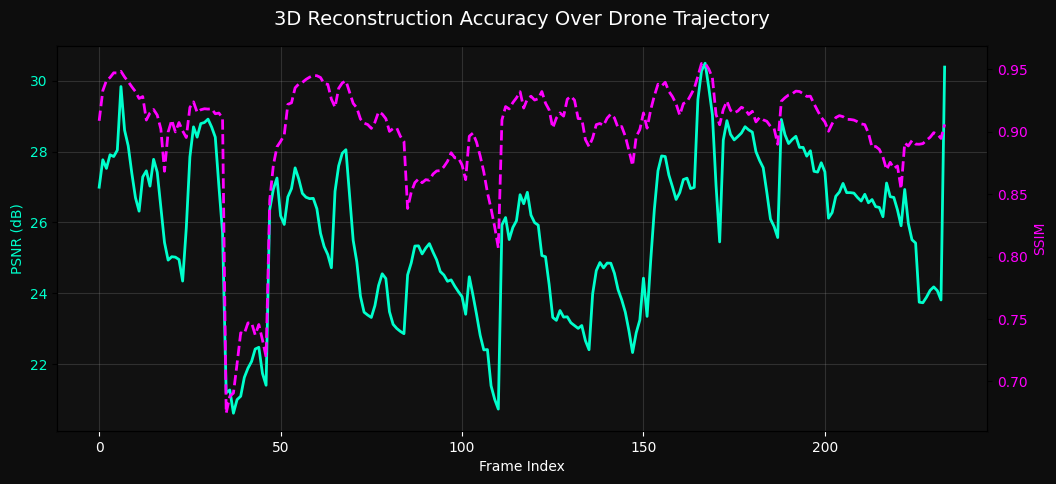

FINAL RECONSTRUCTION METRICS
Average PSNR : 25.74 dB  (>25 is good)
Average SSIM : 0.8989       (>0.8 is excellent)


In [ ]:
# CELL 7: 3DGS RENDER VISUALIZATION & METRICS (PSNR + SSIM)
print("Installing scikit-image for SSIM")
!pip install scikit-image -q
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as calculate_ssim

with open('/content/env_vars.txt', 'r') as f:
    DATA_PATH, DRIVE_ROOT = f.read().splitlines()

UNDISTORTED_DIR = f"{DATA_PATH}/undistorted"
OUTPUT_DIR = '/content/3dgs_workspace'
ITERATIONS = 30000

os.chdir('/content/gaussian-splatting')

print("\nRendering synthetic views from the trained 3DGS model...")
!python render.py -m {OUTPUT_DIR} -s {UNDISTORTED_DIR} --quiet

render_path = f"{OUTPUT_DIR}/train/ours_{ITERATIONS}/renders"
gt_path = f"{OUTPUT_DIR}/train/ours_{ITERATIONS}/gt"

renders = sorted(glob.glob(f"{render_path}/*.png"))
gts = sorted(glob.glob(f"{gt_path}/*.png"))

if len(renders) > 0 and len(gts) > 0:
    print(f"\nRendering complete. Calculating metrics across {len(renders)} frames...")

    def calculate_psnr(img1, img2):
        mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
        if mse == 0: return float('inf')
        return 20 * np.log10(255.0 / np.sqrt(mse))

    psnr_scores = []
    ssim_scores = []
    for r_img, g_img in zip(renders, gts):
        render_img = cv2.imread(r_img)
        gt_img = cv2.imread(g_img)

        psnr = calculate_psnr(gt_img, render_img)
        ssim = calculate_ssim(gt_img, render_img, channel_axis=2)

        psnr_scores.append(psnr)
        ssim_scores.append(ssim)

    # The Performance Graph
    fig_graph, ax1 = plt.subplots(figsize=(12, 5))
    fig_graph.patch.set_facecolor('#0d0d0d')
    ax1.set_facecolor('#111111')

    frames = np.arange(len(renders))

    # Dual Axis: PSNR, SSIM
    color1 = '#00ffcc'
    ax1.set_xlabel('Frame Index', color='white')
    ax1.set_ylabel('PSNR (dB)', color=color1)
    line1 = ax1.plot(frames, psnr_scores, color=color1, label='PSNR', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.tick_params(axis='x', colors='white')

    ax2 = ax1.twinx()
    color2 = '#ff00ff'
    ax2.set_ylabel('SSIM', color=color2)
    line2 = ax2.plot(frames, ssim_scores, color=color2, label='SSIM', linewidth=2, linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('3D Reconstruction Accuracy Over Drone Trajectory', color='white', fontsize=14, pad=15)
    ax1.grid(True, alpha=0.2)

    os.makedirs(f"{DRIVE_ROOT}/renders", exist_ok=True)
    graph_path = f"{DRIVE_ROOT}/renders/metrics_graph.png"
    plt.savefig(graph_path, facecolor='#0d0d0d', bbox_inches='tight')
    plt.show()

    print("="*50)
    print("FINAL RECONSTRUCTION METRICS")
    print("="*50)
    print(f"Average PSNR : {np.mean(psnr_scores):.2f} dB  (>25 is good)")
    print(f"Average SSIM : {np.mean(ssim_scores):.4f}       (>0.8 is excellent)")
    print("="*50)

else:
    print("\nError: Could not find rendered images. Ensure Cell 5 completed fully.")